In [ ]:
from optical_tagging import OpticalTagging
import pandas as pd

sessions = [
    {
        'behavior_json_file': '/root/capsule/data/ecephys_770803_2025-03-24_14-05-57/behavior/770803_2025-03-24_14-05-57.json',
        'ephys_nwb_file': '/root/capsule/data/ecephys_770803_2025-03-24_14-05-57_sorted_2025-03-25_09-00-16/nwb/ecephys_770803_2025-03-24_14-05-57_experiment1_recording1.nwb'
    },
    {
        'behavior_json_file': '/root/capsule/data/ecephys_770803_2025-03-25_13-55-24/behavior/770803_2025-03-25_13-55-24.json',
        'ephys_nwb_file': '/root/capsule/data/ecephys_770803_2025-03-25_13-55-24_sorted_2025-03-30_05-01-48/nwb/ecephys_770803_2025-03-25_13-55-24_experiment1_recording1.nwb'
    },
    {
        'behavior_json_file': '/root/capsule/data/ecephys_770803_2025-03-21_13-20-31/behavior/770803_2025-03-21_13-20-31.json',
        'ephys_nwb_file': '/root/capsule/data/ecephys_770803_2025-03-21_13-20-31_sorted_2025-03-25_11-07-37/nwb/ecephys_770803_2025-03-21_13-20-31_experiment1_recording1.nwb'
    },
]

all_results = []

for session in sessions:
    print(f"\nProcessing: {session['behavior_json_file']}")
    OptoTag = OpticalTagging(behavior_json_file=session['behavior_json_file'],
                             ephys_nwb_file=session['ephys_nwb_file'])
    
    OptoTag.find_significant_units(stim_window=(0.01, 0.04), baseline_window=(-0.03, -0.01))
    
    session_date = session['behavior_json_file'].split('/')[-1].replace('.json', '')
    OptoTag.significant_df['session'] = session_date
    
    all_results.append(OptoTag.significant_df)
    
    # Save individual session result
    OptoTag.significant_df.to_csv(f'/root/capsule/scratch/sig_{session_date}.csv')
    print(f"Saved: sig_{session_date}.csv")

# Combine all sessions into one dataframe
combined_df = pd.concat(all_results, ignore_index=True)
combined_df.to_csv('/root/capsule/scratch/sig_770803_all_sessions.csv')
print("\nAll sessions complete. Combined results saved.")

In [ ]:
# Load a single session without re-running cell 1.
# Recreates the OptoTag object (reads NWB only, no recompute of significance)
# and loads the previously saved significance CSV.

# Reload code from optical_tagging.py automatically on every run (picks up edits without kernel restart)
%load_ext autoreload
%autoreload 2

import glob
from optical_tagging import OpticalTagging

session_date = '770803_2025-03-21_13-20-31'
session_date = '770803_2025-03-24_14-05-57'
behavior_json_file = f'/root/capsule/data/ecephys_{session_date}/behavior/{session_date}.json'

# The sorted folder has an extra timestamp not contained in session_date,
# so locate it by glob (one match expected per session).
ephys_nwb_file = glob.glob(
    f'/root/capsule/data/ecephys_{session_date}_sorted_*/nwb/ecephys_{session_date}_experiment1_recording1.nwb'
)[0]

OptoTag = OpticalTagging(
    behavior_json_file=behavior_json_file,
    ephys_nwb_file=ephys_nwb_file
)

sig_csv_path = f'/root/capsule/scratch/sig_{session_date}.csv'
print(f"OptoTag ready. Significance CSV: {sig_csv_path}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Behavior data successfully loaded from: /root/capsule/data/ecephys_770803_2025-03-24_14-05-57/behavior/770803_2025-03-24_14-05-57.json
Number of units passing the default QC: 380
OptoTag ready. Significance CSV: /root/capsule/scratch/sig_770803_2025-03-24_14-05-57.csv


In [10]:
import pandas as pd
import types

# Step 1: Load the CSV file (saved by cell 1 / load cell into /root/capsule/scratch/)
df = pd.read_csv(sig_csv_path)

# Step 2: Fix the 'condition' column which contains np.float64(...) strings
fake_np = types.SimpleNamespace(float64=float)

def safe_parse_condition(x):
    if isinstance(x, str):
        try:
            return eval(x, {"np": fake_np})
        except Exception as e:
            print(f"Failed to parse: {x}\nError: {e}")
            return None
    return x

df['condition'] = df['condition'].apply(safe_parse_condition)

# Step 3: Define the condition you are interested in
target_cond = (5.0, '1', "Laser_1", 1.0, 5.0, 0.05)
probe="ProbeA"
shank=2

# Step 4: Filter significant rows with stim_FR_mean > baseline_FR_mean
sigrows = df[
    (df["condition"] == target_cond) &
    (df["significant"] == True) &
    (df["stim_FR_mean"] > df["baseline_FR_mean"]) &
    (df["probe"] == probe) 
]

sigrows_increase = df[
    (df["condition"] == target_cond) &
    (df["significant"] == True) &
    (df["stim_FR_mean"] > df["baseline_FR_mean"]) &
    (df["probe"] == probe) &
    (df["shank"] == shank)
]

sigrows_decrease = df[
    (df["condition"] == target_cond) &
    (df["significant"] == True) &
    (df["stim_FR_mean"] < df["baseline_FR_mean"]) &
    (df["probe"] == probe) &
    (df["shank"] == shank)
]


general_rows = df[
    (df["condition"] == target_cond) &
    (df["probe"] == probe) &
    (df["shank"] == shank)
]



print(sigrows)
print(sigrows.shape)
print(general_rows.shape)
# Step 5: Intersect with units passing QC from the OpticalTagging object
common_units = list(set(OptoTag.units_passing_qc.index) & set(sigrows['unit_id']))
print(common_units)
print(len(common_units))


# step 6
import pandas as pd

# Collect the sets of unit IDs
all_units = list(set(OptoTag.units_passing_qc.index) & set(general_rows['unit_id']))
sig_increase_units = set(OptoTag.units_passing_qc.index) & set(sigrows_increase['unit_id'])
sig_decrease_units = set(OptoTag.units_passing_qc.index) & set(sigrows_decrease['unit_id'])

# Build rows for each unit
records = []
for unit_id in all_units:
    est_x = OptoTag.nwb_ephys_data.units['estimated_x'][unit_id]
    est_y = OptoTag.nwb_ephys_data.units['estimated_y'][unit_id]  # assuming estimated_y exists
    p_value=general_rows[general_rows.unit_id==unit_id]['p_value'].values[0]
    records.append({
        "unit_index": unit_id,
        "sig_increase": (unit_id in sig_increase_units) and (p_value<0.001),
        "sig_decrease": (unit_id in sig_decrease_units) and (p_value<0.001),
        "estimated_x": est_x,
        "estimated_y": est_y,
        "p_value":p_value
    })

# Convert to DataFrame
df_summary = pd.DataFrame(records)

# Preview
print(df_summary.head())





      Unnamed: 0                          condition  unit_id       p_value  \
3041        3041  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)       10  3.554857e-04   
3043        3043  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)       29  4.056823e-02   
3044        3044  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)       32  9.213159e-55   
3045        3045  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)       44  3.608789e-03   
3046        3046  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)       50  4.096758e-02   
...          ...                                ...      ...           ...   
3414        3414  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)      868  3.491236e-22   
3416        3416  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)      871  2.235554e-27   
3417        3417  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)      875  7.023620e-06   
3418        3418  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)      882  2.171784e-37   
3419        3419  (5.0, 1, Laser_1, 1.0, 5.0, 0.05)      887  1.367868e-22   

      significant  baseline_FR_mean  stim_FR_mean  baseline_FR_

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


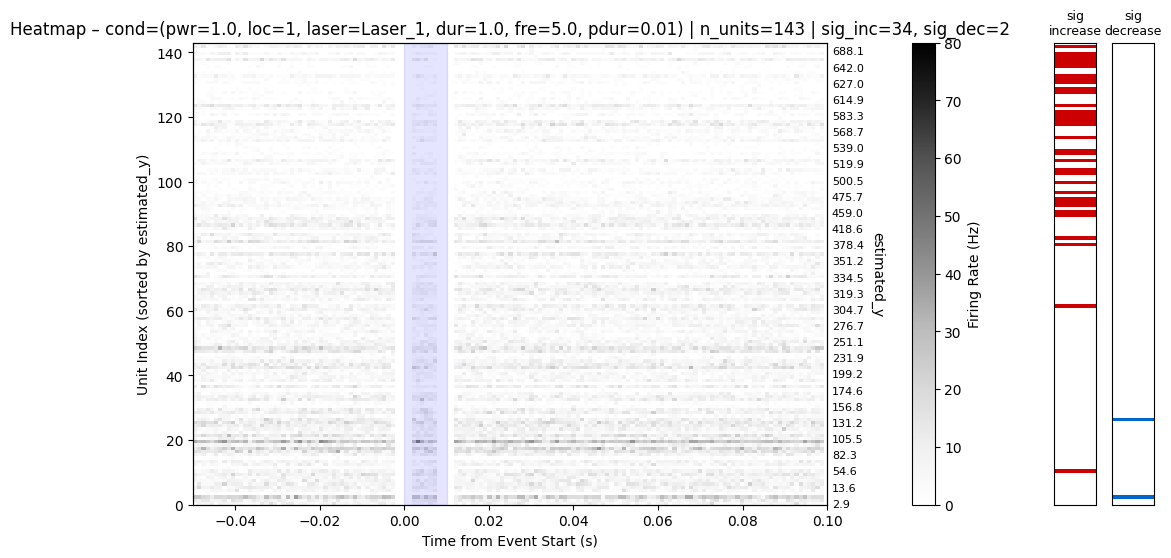

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


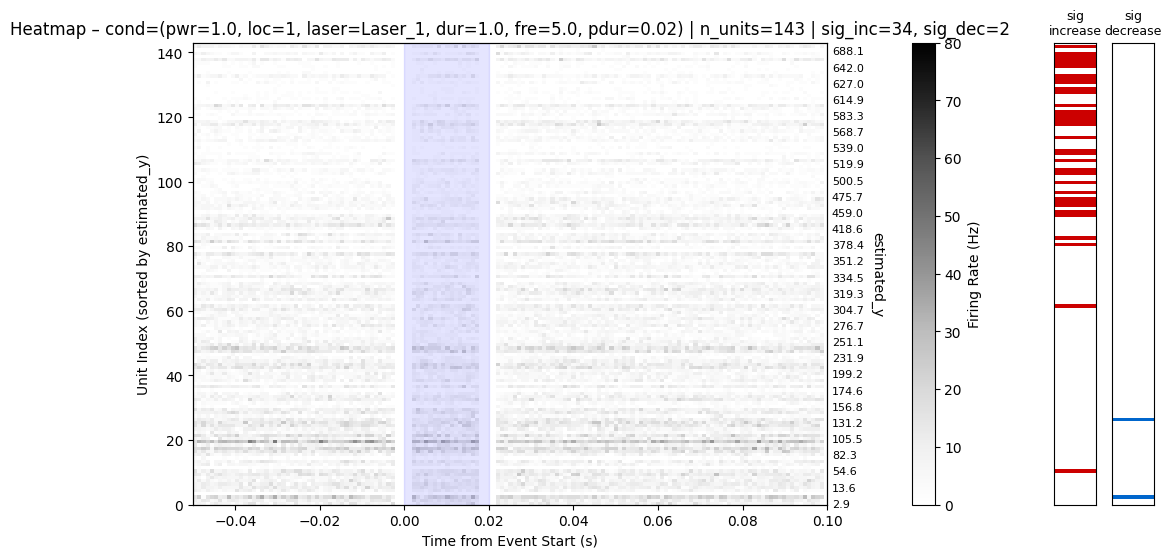

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


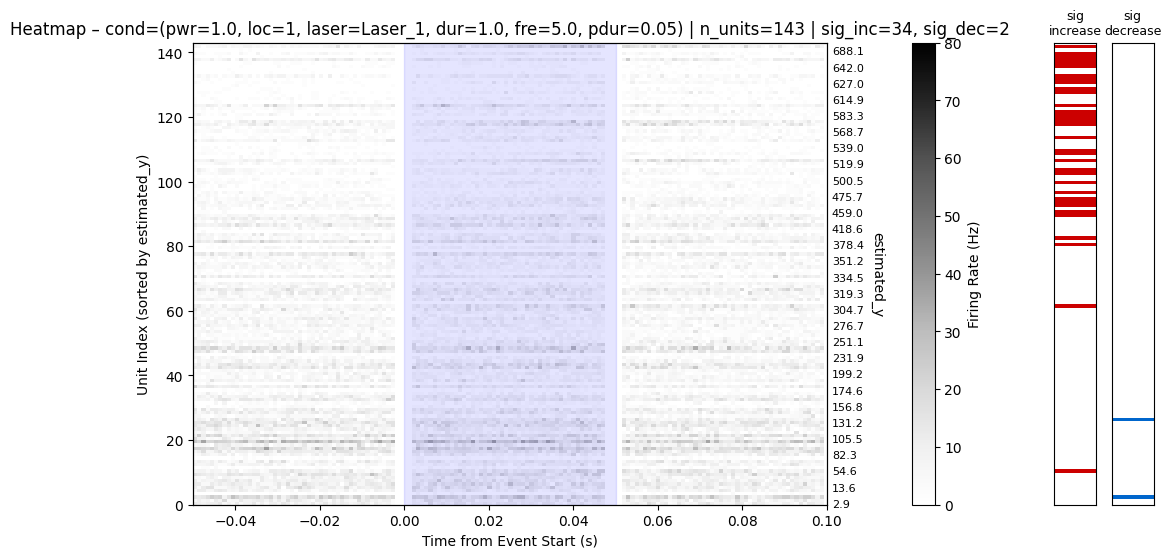

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


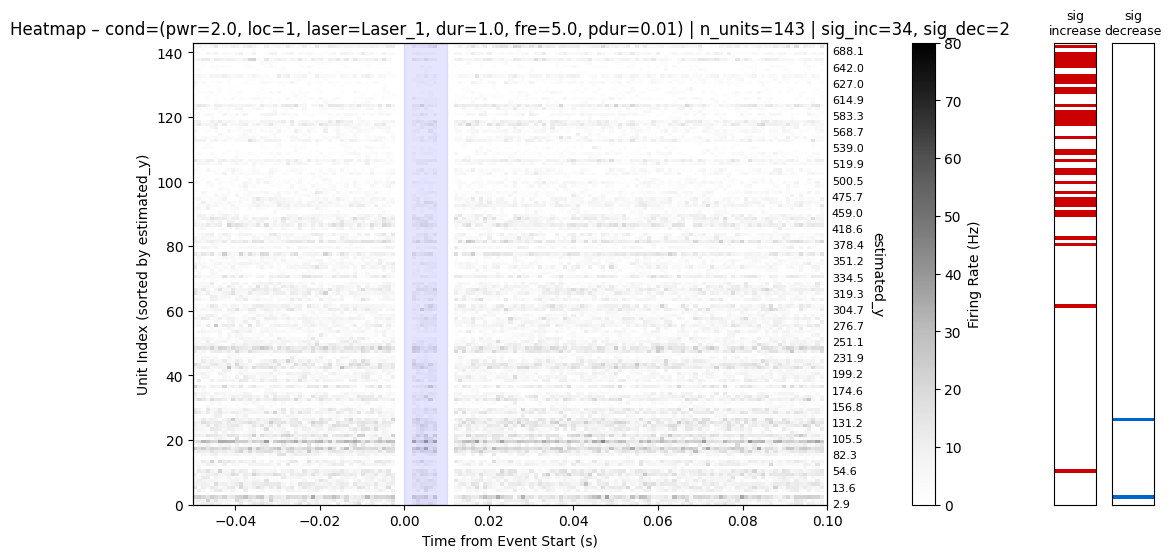

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


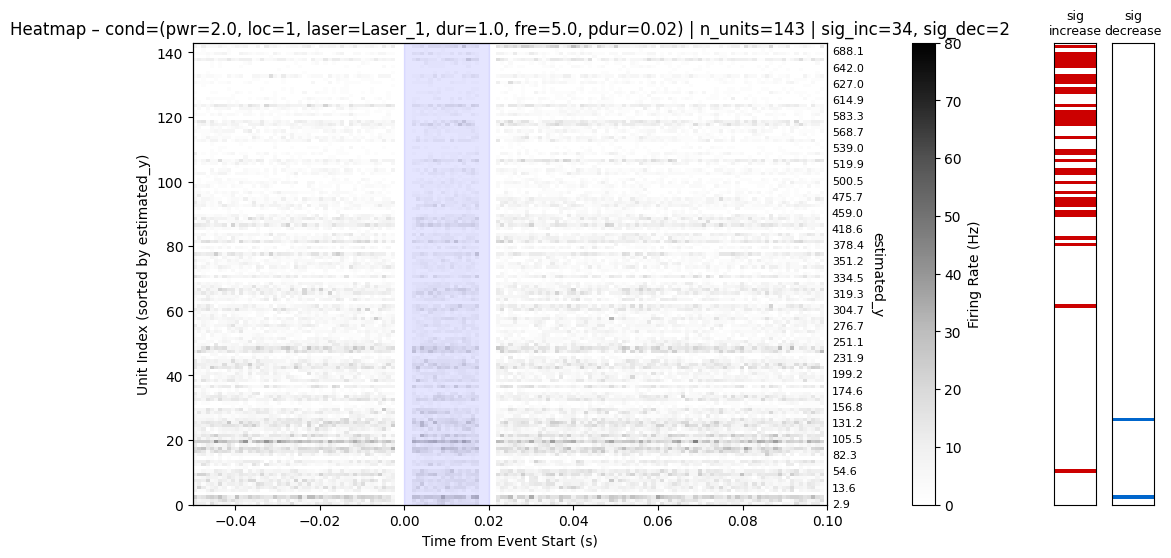

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


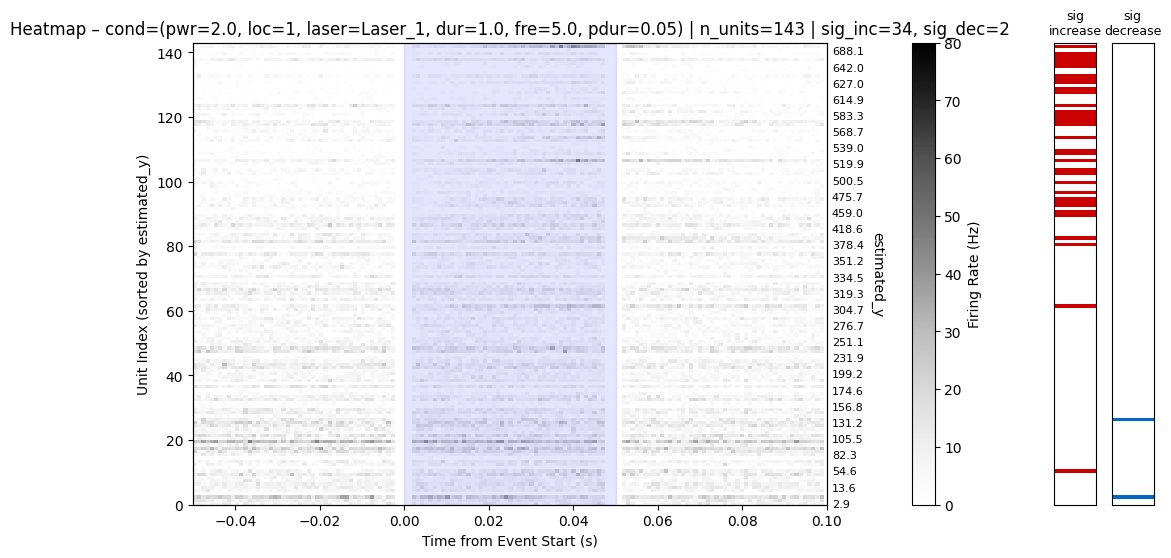

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


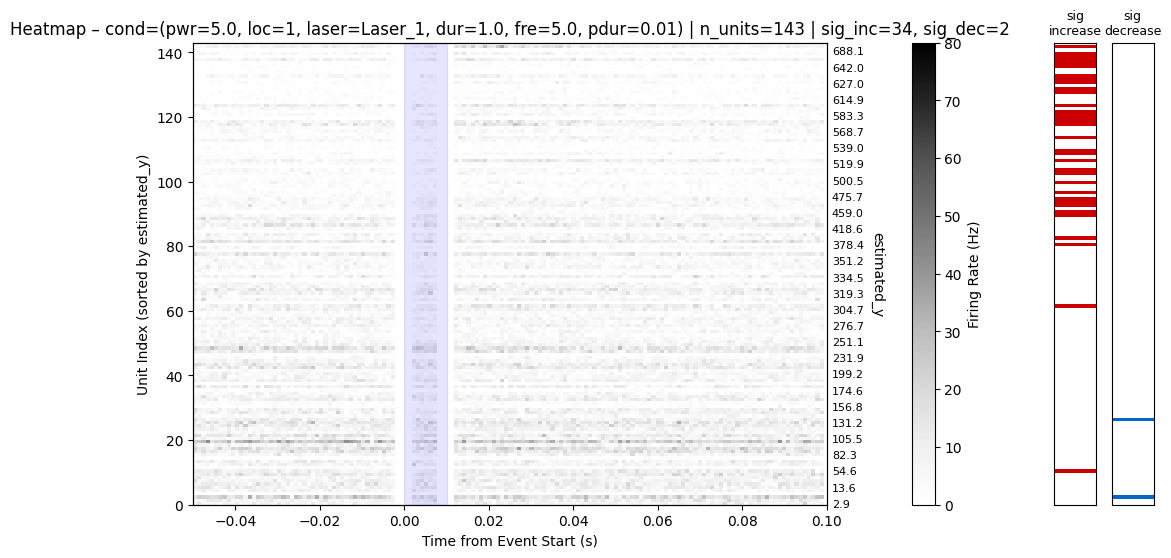

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


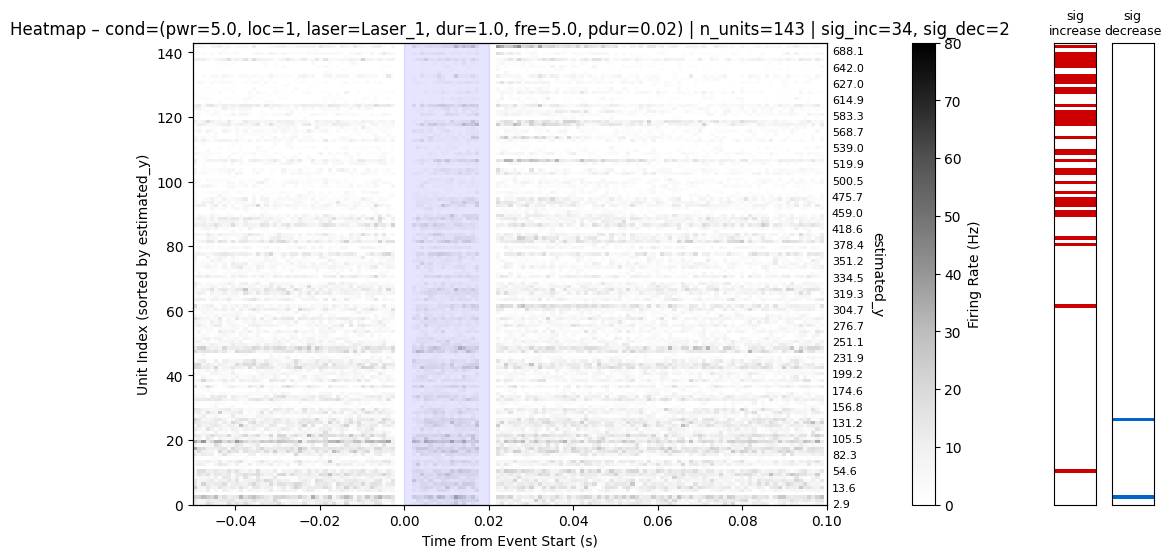

/root/capsule/code/Class.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fmt_low = fmt.lower()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


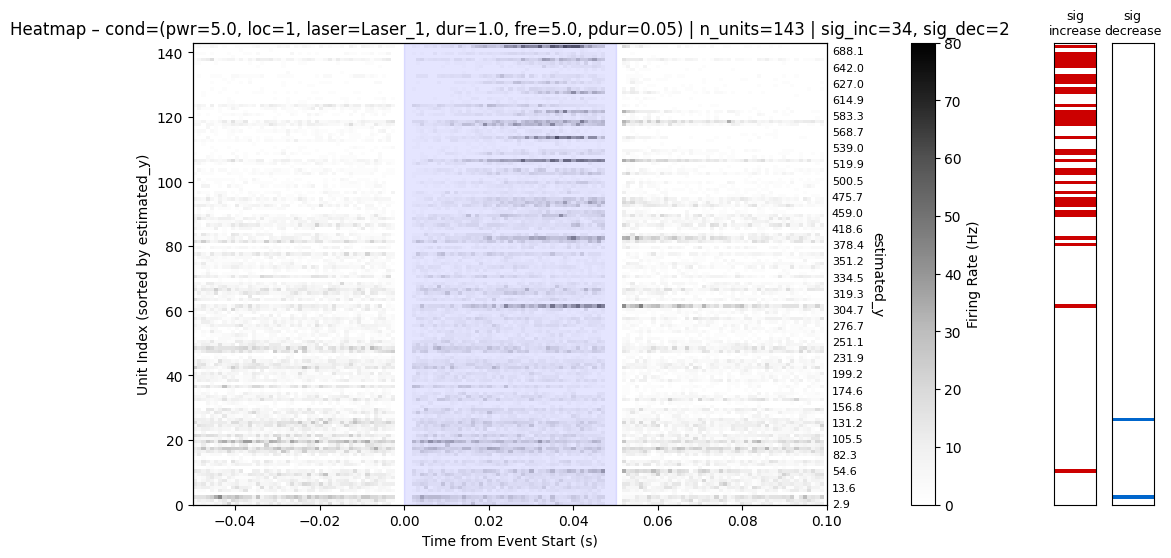

In [15]:
OptoTag.plot_heatmap(unit_index=all_units,df_summary = df_summary,sort_by='estimated_y',bin_size=0.001,time_window=[-0.05,0.1],save_path='/root/capsule/results/heatmap/',show_p_value_line=False)

In [ ]:
len(all_units)

In [ ]:
idx_max = (sigrows["stim_FR_mean"] - sigrows["baseline_FR_mean"]).idxmax()
row_max = sigrows.loc[idx_max]

In [ ]:
row_max

In [ ]:
OptoTag.plot_waveform_mean(unit_id=380,save_formats=["eps"])

In [ ]:
OptoTag.plot_raster_graph(unit_index=380,bin_size=0.002,time_window=[-0.05, 1],align_to_event="laser",min_onset_time=5,save_formats= ["eps"])

In [ ]:
for u in common_units:
    OptoTag.plot_raster_graph(unit_index=u,bin_size=0.002,align_to_event="pulse")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


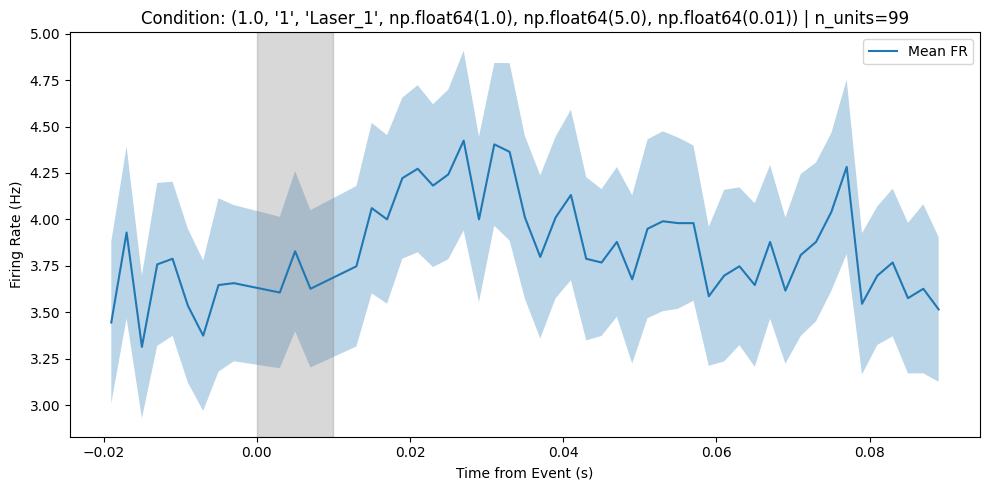

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


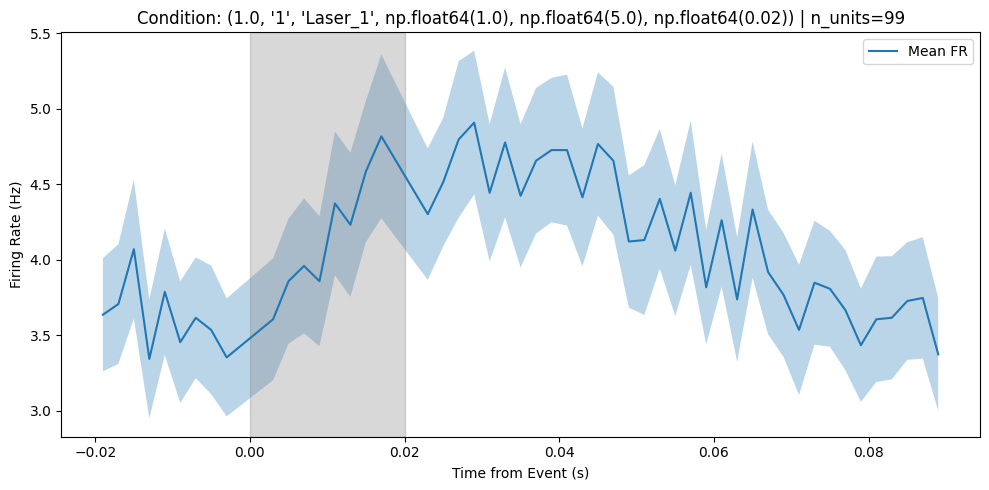

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


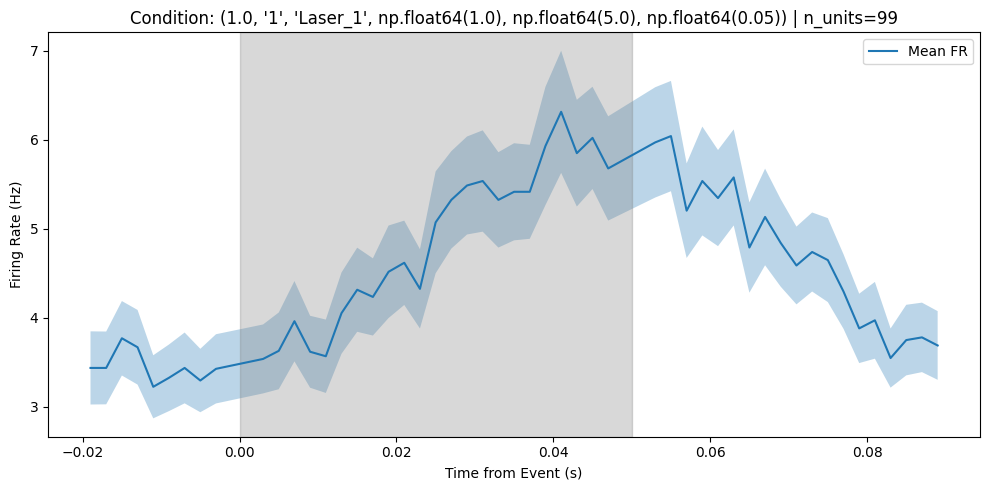

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


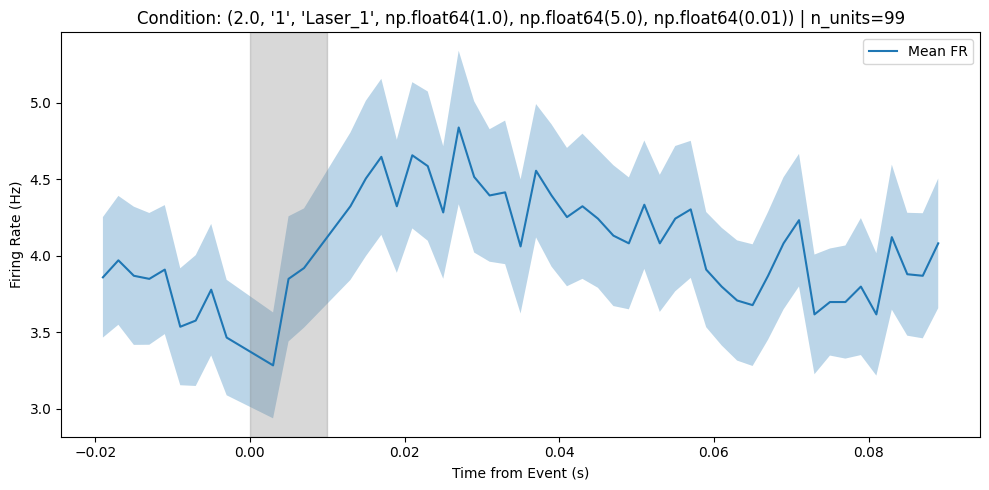

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


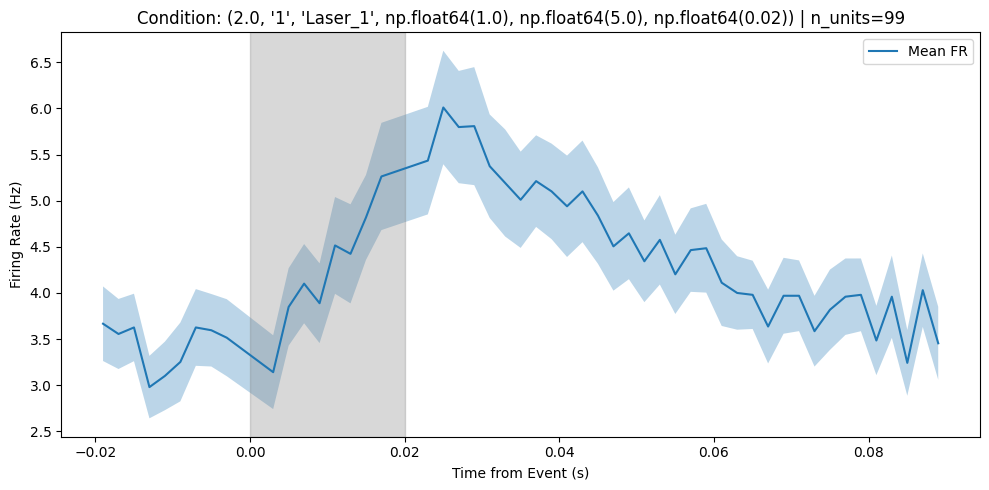

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


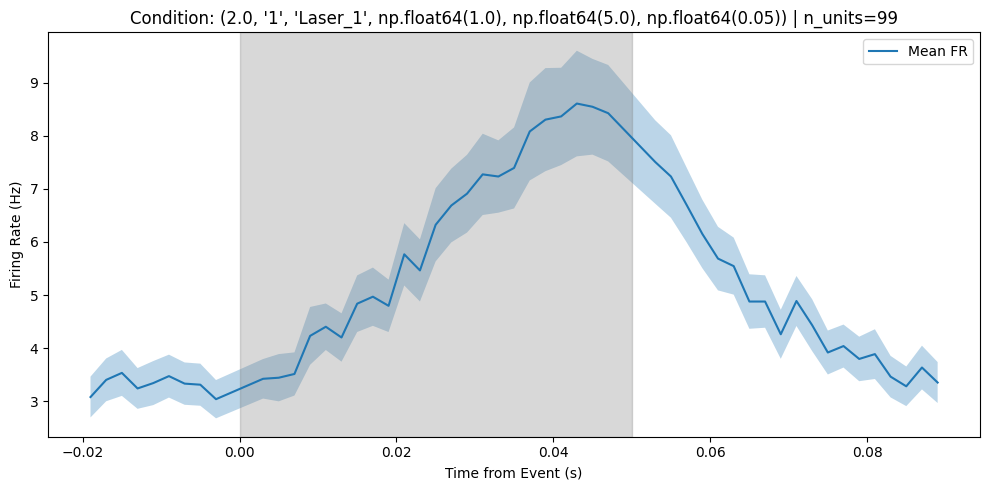

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


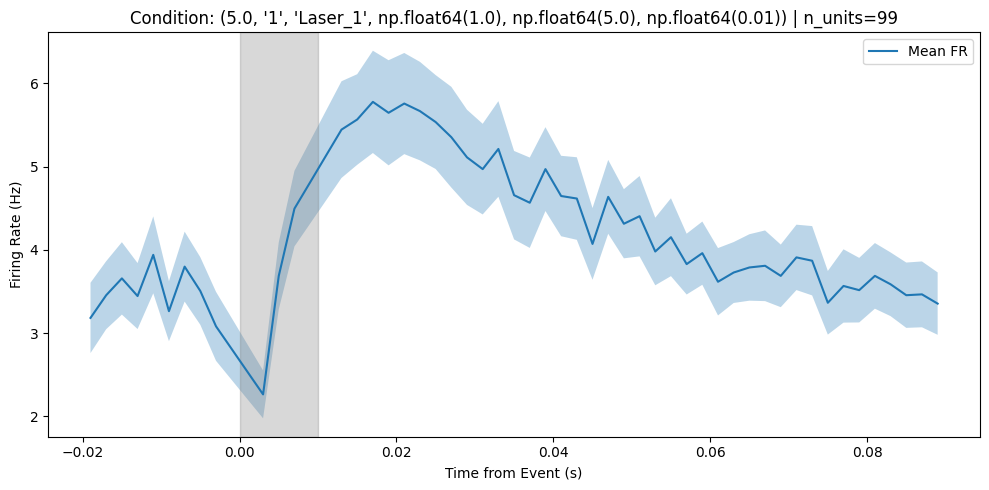

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


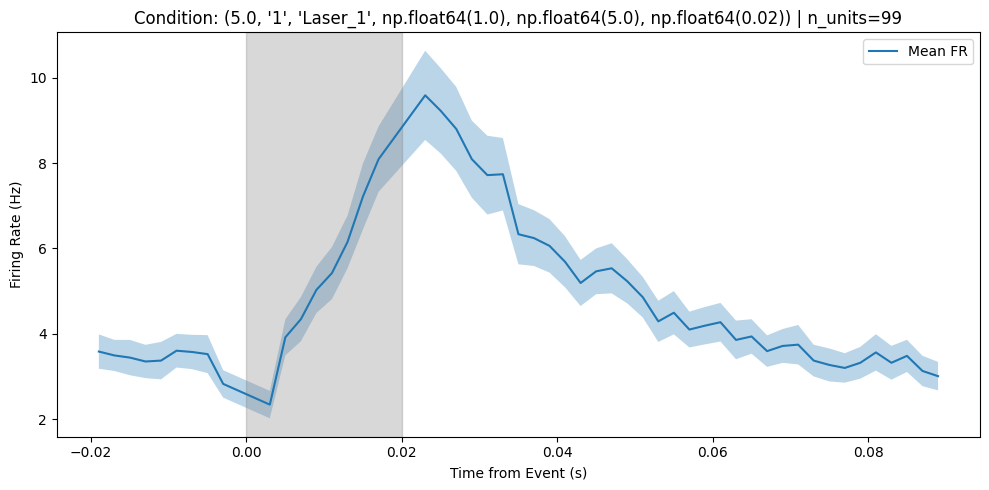

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


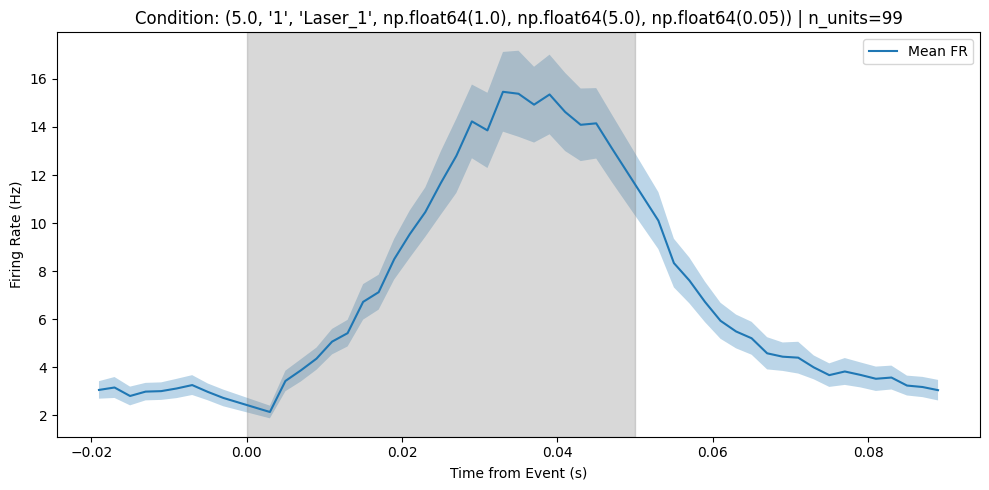

In [19]:
OptoTag.plot_psth(unit_index=common_units,bin_size=0.002,time_window=[-0.02, 0.09],removal_window=0.002,align_to_event='pulse',remove_artefacts=True)

/root/capsule/code/Class.py:1056: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(0, pdur, color=_lighten("gray", amount=0.6), edgecolor="none", zorder=0)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


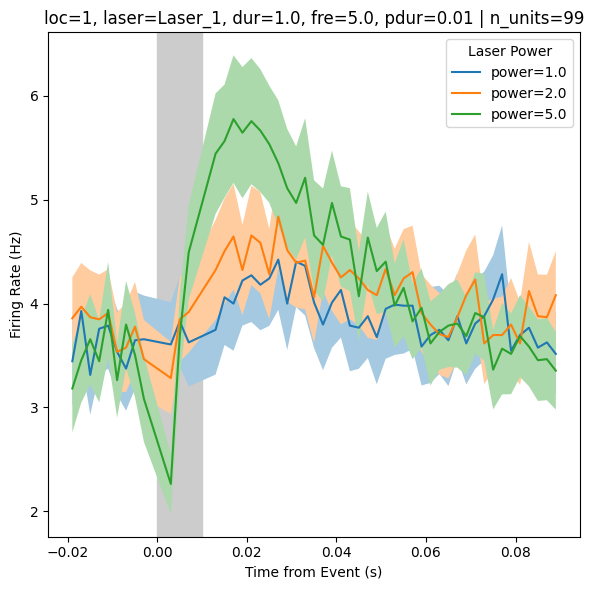

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


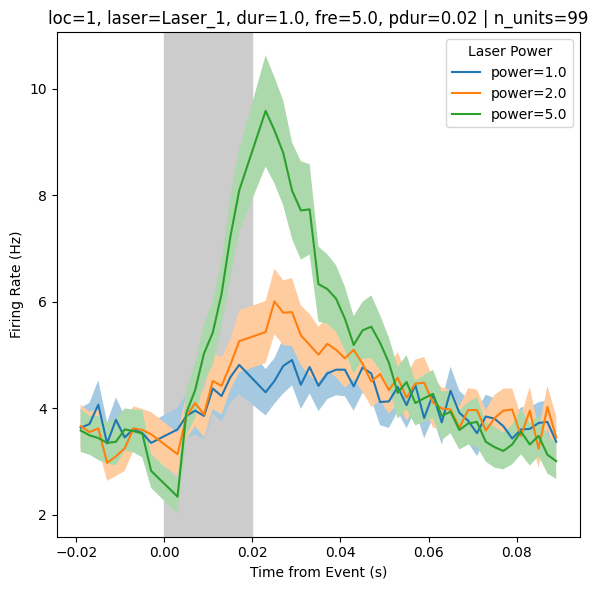

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


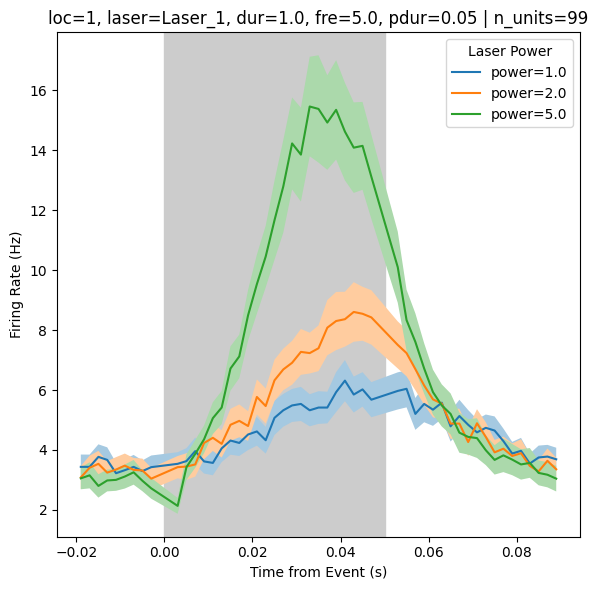

In [6]:
OptoTag.plot_psth_multiple_laser_power(unit_index=common_units,bin_size=0.002,time_window=[-0.02, 0.09],removal_window=0.002,align_to_event='pulse',remove_artefacts=True)

In [ ]:
len(all_units)

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


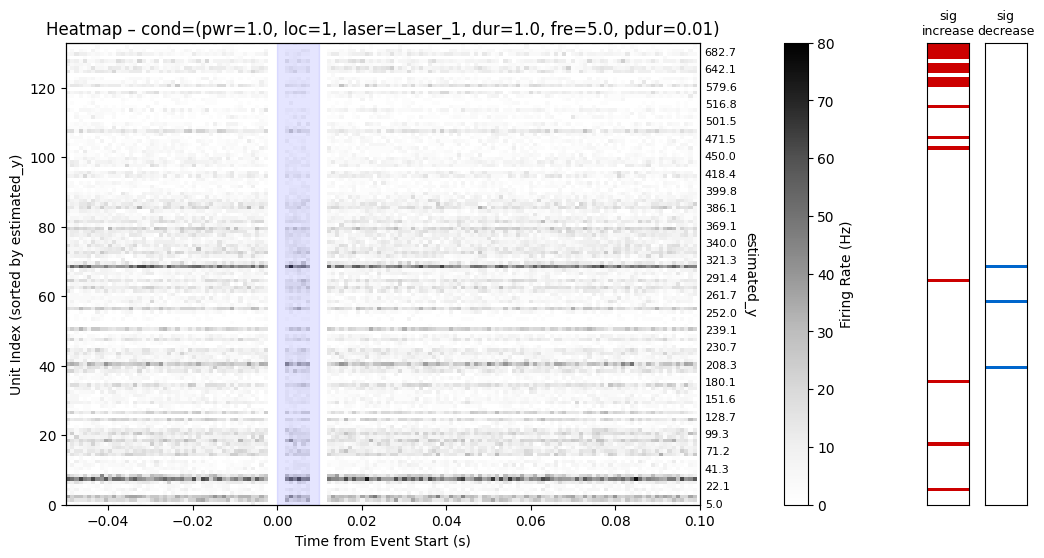

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


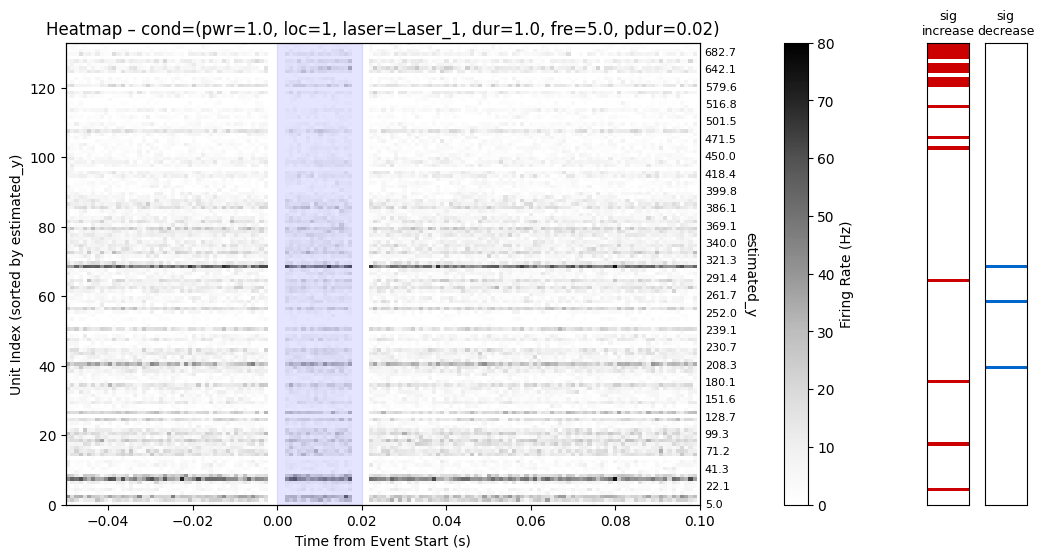

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


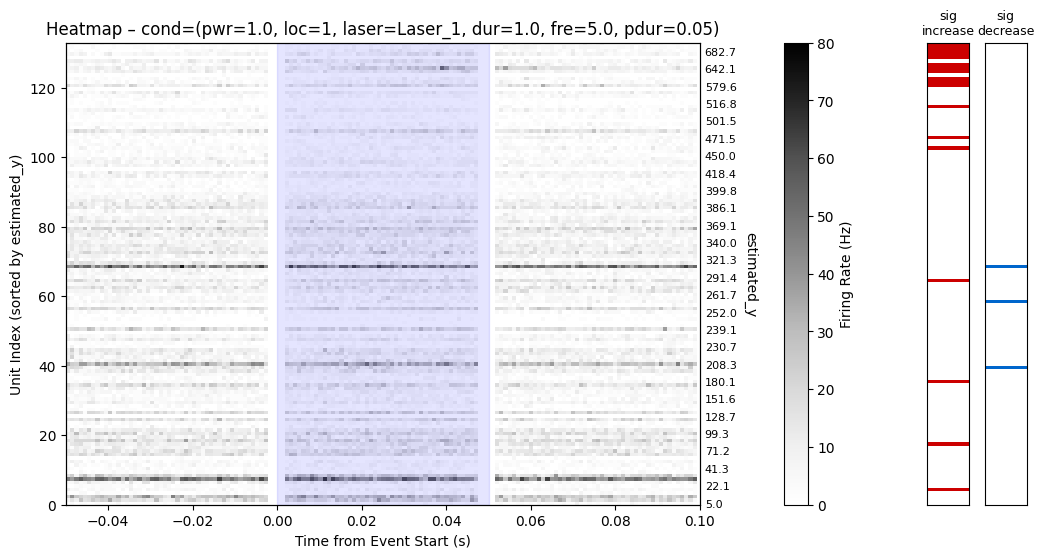

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


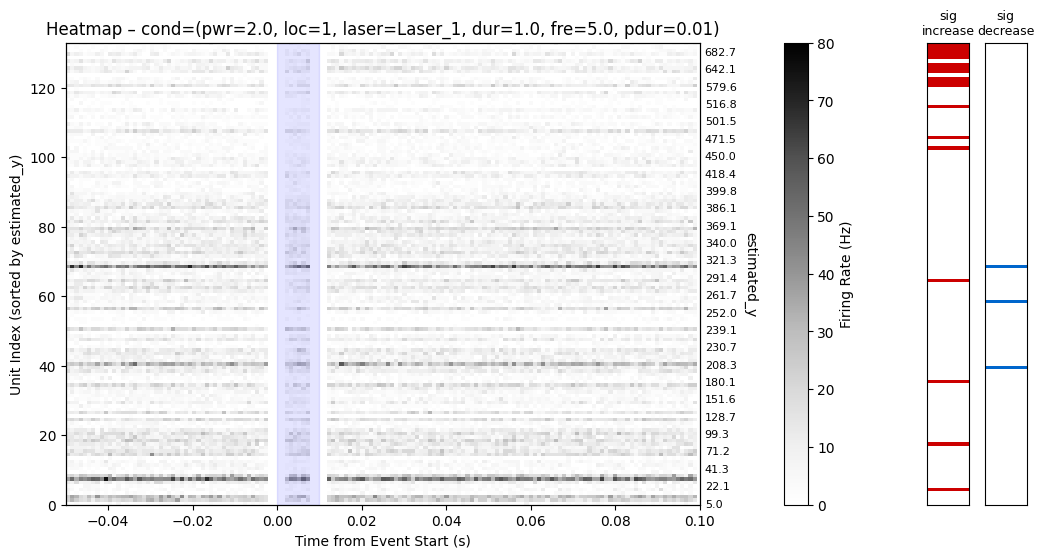

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


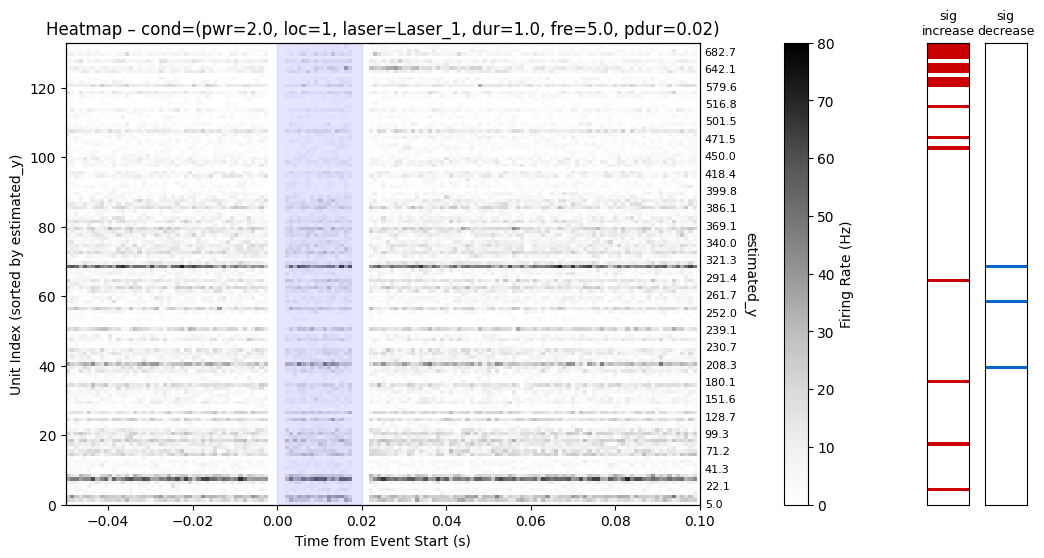

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


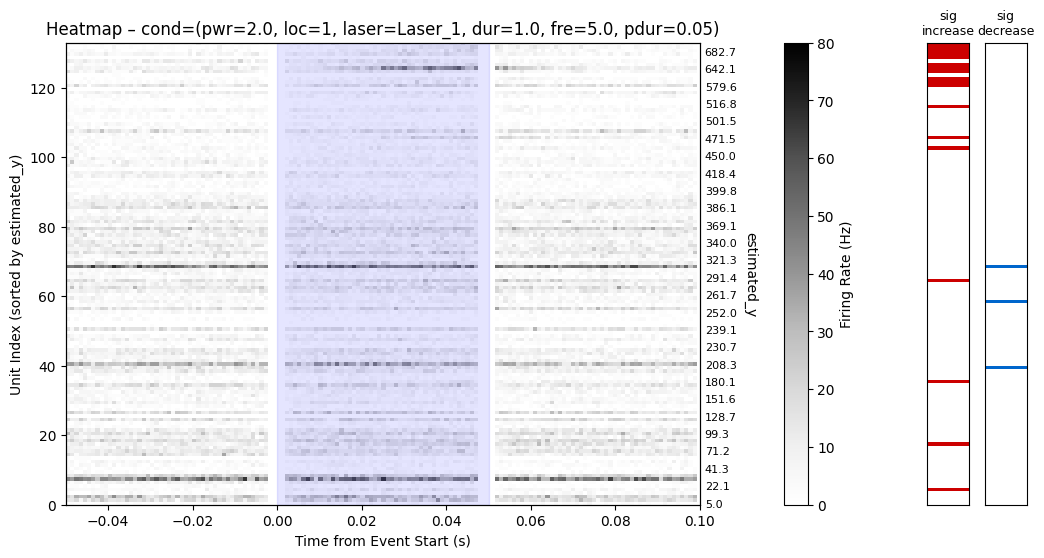

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


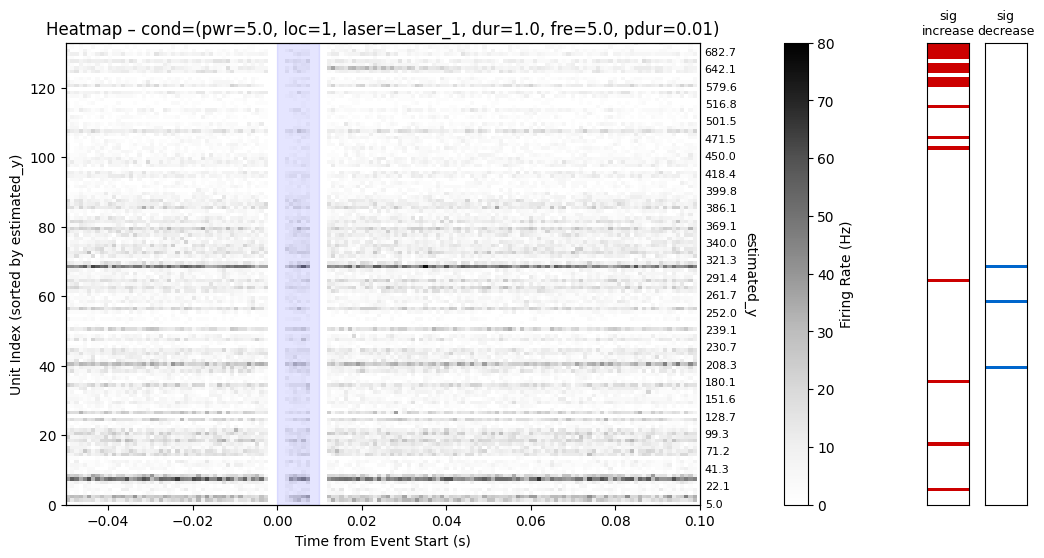

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


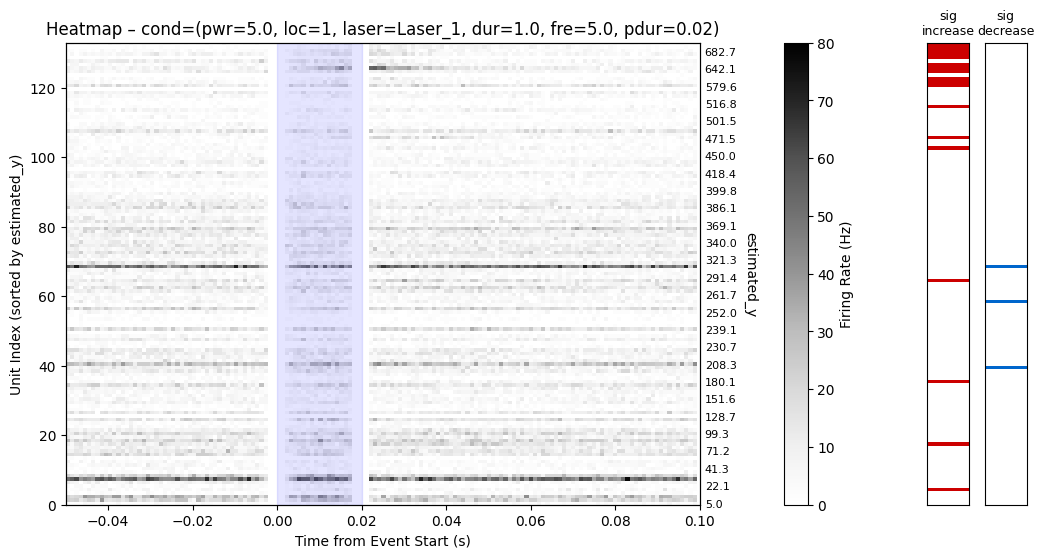

/root/capsule/code/Class.py:1319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


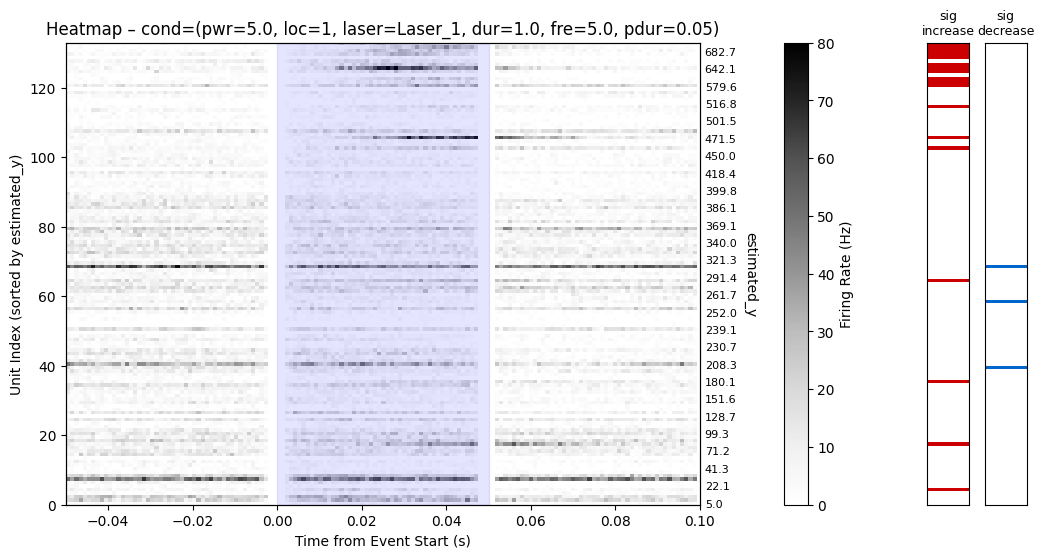

In [7]:
OptoTag.plot_heatmap(unit_index=all_units,df_summary = df_summary,sort_by='estimated_y',bin_size=0.001,time_window=[-0.05,0.1],save_path='/root/capsule/results/heatmap/',show_p_value_line=False)

In [ ]:
OptoTag.plot_psth_align_to_pulse(unit_index=common_units,bin_size=0.005,time_window=[-0.05,0.09],save_path='/root/capsule/results/',y_lim=[0,100])